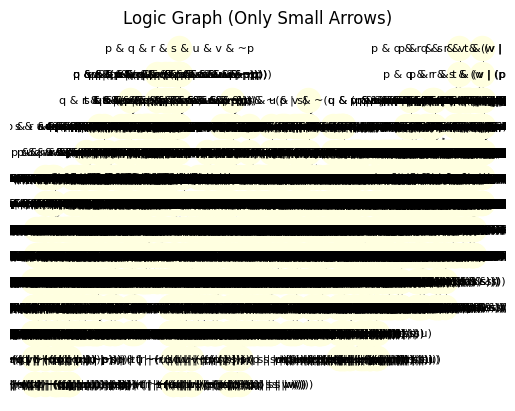

In [ ]:
import sympy
import networkx as nx
import matplotlib.pyplot as plt
import random

def generate_logic_graph_custom(num_atoms, max_depth):
    atoms = [sympy.symbols(chr(ord('p') + i)) for i in range(num_atoms)]  # 生成原子命题
    G = nx.DiGraph()
    seen = set()
    #queue = [(atom, 0) for atom in atoms]
    queue = [(atoms[0],0)]

    while queue:
        current, depth = queue.pop(0)
        current_str = str(current)
        if current_str not in G:
            G.add_node(current_str)

        if depth >= max_depth:
            continue

        # 1. not p × p
        not_expr = ~current
        not_str = str(not_expr)
        if not_str not in seen:
            G.add_node(not_str)
            G.add_edge(current_str, not_str, type='×')
            G.add_edge(not_str, current_str, type='×')
            seen.add(not_str)
            queue.append((not_expr, depth + 1))

        # 2. p → (p ∨ r)
        rand_atom = random.choice(atoms)
        or_expr = current | rand_atom
        or_str = str(or_expr)
        if or_str not in seen:
            G.add_node(or_str)
            G.add_edge(current_str, or_str, type='→')
            seen.add(or_str)
            queue.append((or_expr, depth + 1))
        elif not G.has_edge(current_str, or_str):
            G.add_edge(current_str, or_str, type='→')

        # 3. (p ∧ r) → p
        rand_atom = random.choice(atoms)
        and_expr = current & rand_atom
        and_str = str(and_expr)
        if and_str not in seen:
            G.add_node(and_str)
            G.add_edge(and_str, current_str, type='→')
            seen.add(and_str)
            queue.append((and_expr, depth + 1))
        elif not G.has_edge(and_str, current_str):
            G.add_edge(and_str, current_str, type='→')

    for u, v, d in list(G.edges(data=True)):
        if d['type'] == '→' and G.has_edge(v, u) and G[u][v]['type'] == '→':
            G[u][v]['type'] = '→←'
            G.remove_edge(v, u)

    return G, atoms

def draw_only_small_arrows(G):
    try:
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
        edge_labels = nx.get_edge_attributes(G, 'type')

        nx.draw_networkx_nodes(G, pos, node_color='lightyellow')
        nx.draw_networkx_labels(G, pos, font_size=8)

        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)

        plt.title("Logic Graph (Only Small Arrows)")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print("Graphviz layout failed:", e)


logic_graph, atoms = generate_logic_graph_custom(num_atoms=8, max_depth=8)
draw_only_small_arrows(logic_graph)

In [ ]:
def connect_k_nodes(G, nodes):

    k = len(nodes)
    best = None

    for perm in itertools.permutations(nodes, k):
        all_edges = set()
        walk = []
        valid = True
        for i in range(k - 1):
            p_nodes, p_edges = find_path_with_labels_undirected(G, perm[i], perm[i+1])
            if p_nodes is None:
                valid = False
                break
            if i == 0:
                walk.extend(p_nodes)
            else:
                walk.extend(p_nodes[1:])  
            all_edges |= set(p_edges)
        if not valid:
            continue

        out = {
            'order': perm,
            'walk': walk,
            'edges': list(all_edges),
            'num_edges': len(all_edges),
        }
        if (best is None) or (out['num_edges'] < best['num_edges']):
            best = out

    return best

def find_path_with_labels_undirected(G, source, target):

    H = G.to_undirected()
    try:
        node_path = nx.shortest_path(H, source=source, target=target)
    except nx.NetworkXNoPath:
        return None, None

    labeled = []
    for i in range(len(node_path) - 1):
        u, v = node_path[i], node_path[i+1]
        if G.has_edge(u, v):
            et = G[u][v].get('type', '')
        elif G.has_edge(v, u):
            orig = G[v][u].get('type', '')
            if orig == '→':
                et = '←'
            elif orig == '←':
                et = '→'
            else:
                et = orig  
        else:
            et = 'unknown'
        labeled.append((u, et, v))
    return node_path, labeled

In [ ]:
import itertools
import json, random
import sympy as sp
import networkx as nx


def _count_atoms_in_expr(expr_str):
    try:
        expr = sp.sympify(expr_str)
        return len(expr.free_symbols)
    except Exception:
        return 0

def _build_atom_buckets(nodes, max_atom=8):

    buckets = {m: [] for m in range(1, max_atom + 1)}
    for n in nodes:
        c = _count_atoms_in_expr(n)
        if 1 <= c <= max_atom:
            buckets[c].append(n)
    return buckets

def _sample_k_nodes_uniform_atomcount(nodes, k, max_atom=8, rng=random):

    buckets_master = _build_atom_buckets(nodes, max_atom=max_atom)
    avail_counts = [m for m in range(1, max_atom + 1) if buckets_master[m]]
    if not avail_counts:
        raise ValueError("There's no enough nodes to sample.")
    M = max(avail_counts)

    buckets = {m: list(buckets_master[m]) for m in range(1, max_atom + 1)}
    selected = set()
    result = []

    for _ in range(k):
        target = rng.randint(1, M)
        candidate = None
        if buckets.get(target):
            candidate_list = buckets[target]
        else:
            non_empty = [m for m in range(1, max_atom + 1) if buckets.get(m)]
            if not non_empty:
                break
            m2 = rng.choice(non_empty)
            candidate_list = buckets[m2]

        tried_buckets = set()
        while True:
            if not candidate_list:
                tried_buckets.add(target)
                others = [m for m in range(1, max_atom + 1) if m not in tried_buckets and buckets.get(m)]
                if not others:
                    break
                target = rng.choice(others)
                candidate_list = buckets[target]
                continue
            x = rng.choice(candidate_list)
            if x not in selected:
                candidate = x
                candidate_list.remove(x)
                break
            else:
                candidate_list.remove(x)

        if candidate is None:
            break

        selected.add(candidate)
        result.append(candidate)

    if len(result) < k:
        raise ValueError(f"expected {k} nodes, but only sampled {len(result)}.")

    return result

def sample_and_save_paths_multi_uniform_atoms(
    G,
    num_samples=100,
    k=3,
    out_file="paths_multi.jsonl",
    max_atom_bucket=8,
    rng=random,
):
    nodes = list(G.nodes)
    written = 0
    with open(out_file, "w", encoding="utf-8") as f:
        for i in range(num_samples):
            try:
                selected = _sample_k_nodes_uniform_atomcount(
                    nodes, k, max_atom=max_atom_bucket, rng=rng
                )
            except ValueError as e:
                print(f"[sample {i}] failed to sample: {e}")
                continue

            res = connect_k_nodes(G, selected)
            if not res:
                print(f"[sample {i}] Cannot connect: {selected}")
                continue

            rec = {
                "source_nodes": selected,
                "order": res["order"],
                "walk": res["walk"],
                "edges": res["edges"],
                "num_edges": res["num_edges"],
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            written += 1

            if i % 10 == 0:
                print(f"[{i}/{num_samples}] written={written}")

    return written

In [ ]:
import math
import itertools
import json, random
import sympy as sp
import networkx as nx


def _build_distance_index(G, cutoff=8):
    H = G.to_undirected()
    dist_idx = {}
    for s, lengths in nx.all_pairs_shortest_path_length(H, cutoff=cutoff):
        dist_idx[s] = dict(lengths)
    return dist_idx

def _min_dist_to_set(dist_idx, x, S):
    md = math.inf
    dx = dist_idx.get(x, {})
    for s in S:
        if s in dx:
            md = min(md, dx[s])
    return md

def _max_dist_to_set(dist_idx, x, S):
    dx = dist_idx.get(x, {})
    m = 0
    for s in S:
        if s not in dx:
            return math.inf
        m = max(m, dx[s])
    return m

def _sample_k_nodes_uniform_atomcount_and_distance(
    nodes,
    k,
    dist_idx,
    max_atom=8,
    d_min=1,
    d_max=4,
    far_cap=None,
    tol=0,
    rng=random,
):
    buckets_master = _build_atom_buckets(nodes, max_atom=max_atom)
    avail_counts = [m for m in range(1, max_atom + 1) if buckets_master[m]]
    if not avail_counts:
        raise ValueError("There's no nodes that can be parsed (1..8 atoms) for sampling.")

    buckets = {m: list(buckets_master[m]) for m in range(1, max_atom + 1)}
    selected = []
    selected_set = set()

    m0 = rng.choice(avail_counts)
    if not buckets[m0]:
        non_empty = [m for m in avail_counts if buckets[m]]
        if not non_empty:
            raise ValueError("There's no available nodes.")
        m0 = rng.choice(non_empty)
    x0 = rng.choice(buckets[m0])
    buckets[m0].remove(x0)
    selected.append(x0)
    selected_set.add(x0)

    for t in range(1, k):
        non_empty = [m for m in avail_counts if buckets[m]]
        if not non_empty:
            raise ValueError(f"expected {k} nodes, but only sampled {len(selected)}.")
        m_target = rng.choice(non_empty)

        d_target = rng.randint(d_min, d_max)

        cand_list = buckets[m_target]
        rng.shuffle(cand_list)

        def ok(y, widen=0):
            md = _min_dist_to_set(dist_idx, y, selected)
            if md is math.inf:
                return False
            if not (d_target - (tol + widen) <= md <= d_target + (tol + widen)):
                return False
            if far_cap is not None:
                mx = _max_dist_to_set(dist_idx, y, selected)
                if mx is math.inf or mx > far_cap:
                    return False
            return True

        chosen = None
        for y in cand_list:
            if y in selected_set:
                continue
            if ok(y, widen=0):
                chosen = y
                break

        widen = 1
        while chosen is None and widen <= 2 * (d_max - d_min + 1):
            for y in cand_list:
                if y in selected_set:
                    continue
                if ok(y, widen=widen):
                    chosen = y
                    break
            widen += 1

        if chosen is None:
            for y in cand_list:
                if y in selected_set:
                    continue
                md = _min_dist_to_set(dist_idx, y, selected)
                if md is math.inf:
                    continue
                if d_min <= md <= d_max and (far_cap is None or _max_dist_to_set(dist_idx, y, selected) <= far_cap):
                    chosen = y
                    break

        if chosen is None:
            for y in cand_list:
                if y in selected_set:
                    continue
                md = _min_dist_to_set(dist_idx, y, selected)
                if md is not math.inf and (far_cap is None or _max_dist_to_set(dist_idx, y, selected) <= far_cap):
                    chosen = y
                    break

        if chosen is None:
            all_candidates = []
            for m in non_empty:
                all_candidates.extend([z for z in buckets[m] if z not in selected_set])
            rng.shuffle(all_candidates)
            for y in all_candidates:
                if ok(y, widen=1):
                    chosen = y
                    m_target = _count_atoms_in_expr(y)
                    break

        if chosen is None:
            raise ValueError(f"cannot sample the {t+1}th node; already sampled {len(selected)}.")

        selected.append(chosen)
        selected_set.add(chosen)
        m_real = _count_atoms_in_expr(chosen)
        if 1 <= m_real <= max_atom and chosen in buckets.get(m_real, []):
            buckets[m_real].remove(chosen)
        else:
            if chosen in buckets.get(m_target, []):
                buckets[m_target].remove(chosen)

    return selected

def sample_and_save_paths_multi_uniform_atoms_dist(
    G,
    num_samples=100,
    k=3,
    out_file="paths_multi.jsonl",
    max_atom_bucket=8,
    rng=random,
    cutoff=8,     
    d_min=1,      
    d_max=4,      
    far_cap=6,    
    tol=0,        
):
    nodes = list(G.nodes)
    dist_idx = _build_distance_index(G, cutoff=cutoff)

    written = 0
    with open(out_file, "w", encoding="utf-8") as f:
        for i in range(num_samples):
            try:
                selected = _sample_k_nodes_uniform_atomcount_and_distance(
                    nodes,
                    k,
                    dist_idx=dist_idx,
                    max_atom=max_atom_bucket,
                    d_min=d_min,
                    d_max=d_max,
                    far_cap=far_cap,
                    tol=tol,
                    rng=rng,
                )
            except ValueError as e:
                print(f"[sample {i}] failed to sample: {e}")
                continue

            res = connect_k_nodes(G, selected)
            if not res:
                print(f"[sample {i}] cannot connect: {selected}")
                continue

            rec = {
                "source_nodes": selected,
                "order": res["order"],
                "walk": res["walk"],
                "edges": res["edges"],
                "num_edges": res["num_edges"],
            }
            f.write(json.dumps(rec, ensure_ascii=False) + "\n")
            written += 1
            if i % 10 == 0:
                print(f"[{i}/{num_samples}] written={written}")

    return written


In [6]:
written = sample_and_save_paths_multi_uniform_atoms_dist(logic_graph, num_samples=1000, k=4, out_file="paths4_dist_1.jsonl", max_atom_bucket=8)

[0/1000] written=1
[10/1000] written=11
[20/1000] written=21
[30/1000] written=31
[40/1000] written=41
[50/1000] written=51
[60/1000] written=61
[70/1000] written=71
[80/1000] written=81
[90/1000] written=91
[100/1000] written=101
[110/1000] written=111
[120/1000] written=121
[130/1000] written=131
[140/1000] written=141
[150/1000] written=151
[160/1000] written=161
[170/1000] written=171
[180/1000] written=181
[190/1000] written=191
[200/1000] written=201
[210/1000] written=211
[220/1000] written=221
[230/1000] written=231
[240/1000] written=241
[250/1000] written=251
[260/1000] written=261
[270/1000] written=271
[280/1000] written=281
[290/1000] written=291
[300/1000] written=301
[310/1000] written=311
[320/1000] written=321
[330/1000] written=331
[340/1000] written=341
[350/1000] written=351
[360/1000] written=361
[370/1000] written=371
[380/1000] written=381
[390/1000] written=391
[400/1000] written=401
[410/1000] written=411
[420/1000] written=421
[430/1000] written=431
[440/1000]